In [5]:
# ── CELDA 1: Importaciones ────────────────────────────────────

import sys
import os

# Permite importar módulos desde la raíz del proyecto
sys.path.insert(0, '..')


# ── Librerías de análisis de datos ────────────────────────────
import pandas as pd
import numpy as np


# ── Librerías de visualización ────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns


# ── Librerías estadísticas ────────────────────────────────────
import statsmodels.api as sm


# ── Machine Learning ──────────────────────────────────────────
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ── Conexión a base de datos ──────────────────────────────────
from scripts.database import engine


# ── Configuración visual global ───────────────────────────────
sns.set_theme(
    style="whitegrid",
    palette="muted"
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'figure.figsize': (8, 5)
})


print("✅ Librerías importadas correctamente")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   seaborn    {sns.__version__}")
print("   matplotlib cargado correctamente")
print("   plt disponible para todo el notebook")

✅ Librerías importadas correctamente
   pandas     2.3.3
   numpy      2.4.3
   seaborn    0.13.2
   matplotlib cargado correctamente
   plt disponible para todo el notebook


In [7]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    dp.area_km2,
    dp.poblacion
FROM datos_paises dp
ORDER BY dp.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

# Renombrar columnas para mantener consistencia
df.rename(columns={
    'area_km2': 'Area',
    'poblacion': 'Poblacion',
}, inplace=True)

print("✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📋 Valores nulos:")
print(df.isnull().sum())

print("\n📋 Primeras filas:")
df.head()

✅ Datos cargados desde PostgreSQL
   Filas    : 2,069
   Columnas : 2

📋 Valores nulos:
Area         0
Poblacion    0
dtype: int64

📋 Primeras filas:


,Area,Poblacion
0,15878973.37,214509641
1,3885761.58,6661789
2,3215144.79,51660444
3,2214299.75,236407726
4,16223801.61,72524334


In [8]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────
X = df[['Area']].values
y = df['Poblacion'].values

print(f"X shape: {X.shape}  (variable predictora: Area)")
print(f"y shape: {y.shape}  (variable objetivo:   Poblacion)")

print("\n📊 Estadísticas descriptivas:")
df.describe().round(2)

X shape: (2069, 1)  (variable predictora: Area)
y shape: (2069,)  (variable objetivo:   Poblacion)

📊 Estadísticas descriptivas:


,Area,Poblacion
count,2069.00,2.069000e+03
mean,6805673.68,1.018723e+08
std,5643784.44,9.867980e+07
min,0.49,0.000000e+00
25%,1014037.26,2.073426e+07
50%,6408020.80,8.828392e+07
75%,11718410.97,1.688507e+08
max,17491315.08,1.417492e+09


In [9]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
import os as _os

_GRAFICAS = _os.path.join(
    _os.path.abspath('..'),
    'data',
    'graficas'
)

_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales,
                  save_dir=_GRAFICAS):
    """
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos y predicciones vs. reales.

    En este notebook:
    X = Área del país
    y = Población del país
    """

    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # 1. Partición de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  Test: {X_test.shape[0]:,} muestras")

    # 2. Entrenamiento del modelo
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # 3. Predicciones
    y_pred = modelo.predict(X_test)

    # 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → El modelo explica aproximadamente el {r2*100:.1f}%")
    print("         de la variación de la población según el área del país.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print("       → Penaliza más los errores grandes.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f} habitantes")
    print("       → Error promedio en la misma unidad de la variable objetivo.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f} habitantes")
    print("       → Desviación promedio absoluta de las predicciones.")

    # Guardar resultados
    resultados_globales.append({
        'Split':  split_label,
        'Train%': train_pct,
        'Test%':  test_pct,
        'R²':     round(r2, 4),
        'MSE':    round(mse, 4),
        'RMSE':   round(rmse, 4),
        'MAE':    round(mae, 4),
    })

    # 5. Gráficos
    residuos = y_test - y_pred
    slug = split_label.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'DecisionTreeRegressor — {split_label}',
        fontsize=14,
        fontweight='bold'
    )

    # Gráfico de residuos
    axes[0].scatter(
        y_pred,
        residuos,
        alpha=0.35,
        s=14,
        label='Residuos'
    )

    axes[0].axhline(
        0,
        linestyle='--',
        linewidth=2,
        label='Línea ideal'
    )

    orden_idx = np.argsort(y_pred)

    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx],
        y_pred[orden_idx],
        frac=0.4
    )

    axes[0].plot(
        lowess_res[:, 0],
        lowess_res[:, 1],
        linewidth=2.5,
        label='Tendencia LOWESS'
    )

    axes[0].set_title('Gráfico de Errores / Residuos', fontweight='bold')
    axes[0].set_xlabel('Población predicha')
    axes[0].set_ylabel('Residuo')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Gráfico predicción vs valor real
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())

    axes[1].scatter(
        y_test,
        y_pred,
        alpha=0.30,
        s=14,
        label='Predicciones'
    )

    axes[1].plot(
        [minval, maxval],
        [minval, maxval],
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Población real')
    axes[1].set_ylabel('Población predicha')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    fname = os.path.join(save_dir, f'dt{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


# Contenedor de resultados para el análisis consolidado
resultados_globales = []

print("✅ Función evaluar_split definida correctamente.")
print(f"   Directorio de gráficas: {_GRAFICAS}")

✅ Función evaluar_split definida correctamente.
   Directorio de gráficas: /home/luis/Documents/STREAMLIT-PROYECTO/data/graficas



  Split 1 (80/20) — 80% Train / 20% Test
  Train: 1,655 muestras  |  Test: 414 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.6969  (69.69%)
       → El modelo explica aproximadamente el 69.7%
         de la variación de la población según el área del país.
  MSE  (Error Cuadrático Med): 3282443732008982.5000
       → Penaliza más los errores grandes.
  RMSE (Raíz del MSE)        : 57292614.9867 habitantes
       → Error promedio en la misma unidad de la variable objetivo.
  MAE  (Error Absoluto Med)  : 27088435.3237 habitantes
       → Desviación promedio absoluta de las predicciones.


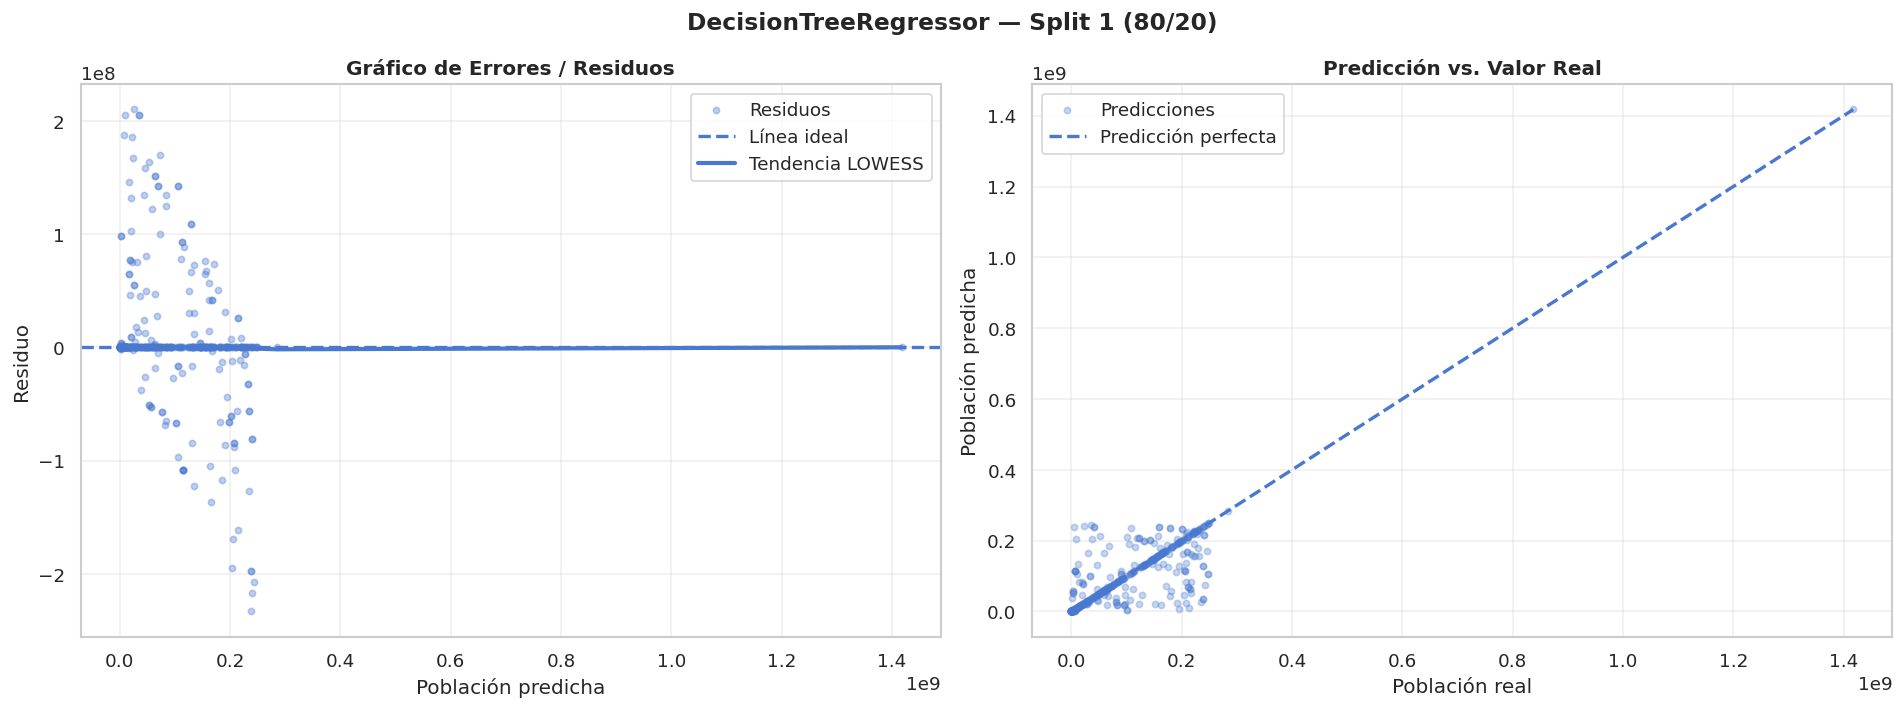

  💾 Gráfico guardado → /home/luis/Documents/STREAMLIT-PROYECTO/data/graficas/dtSplit_1_80-20.png


In [10]:
 # ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X,
    y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 1,448 muestras  |  Test: 621 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.3015  (30.15%)
       → El modelo explica aproximadamente el 30.2%
         de la variación de la población según el área del país.
  MSE  (Error Cuadrático Med): 8627368567354553.0000
       → Penaliza más los errores grandes.
  RMSE (Raíz del MSE)        : 92883629.1677 habitantes
       → Error promedio en la misma unidad de la variable objetivo.
  MAE  (Error Absoluto Med)  : 35625380.2834 habitantes
       → Desviación promedio absoluta de las predicciones.


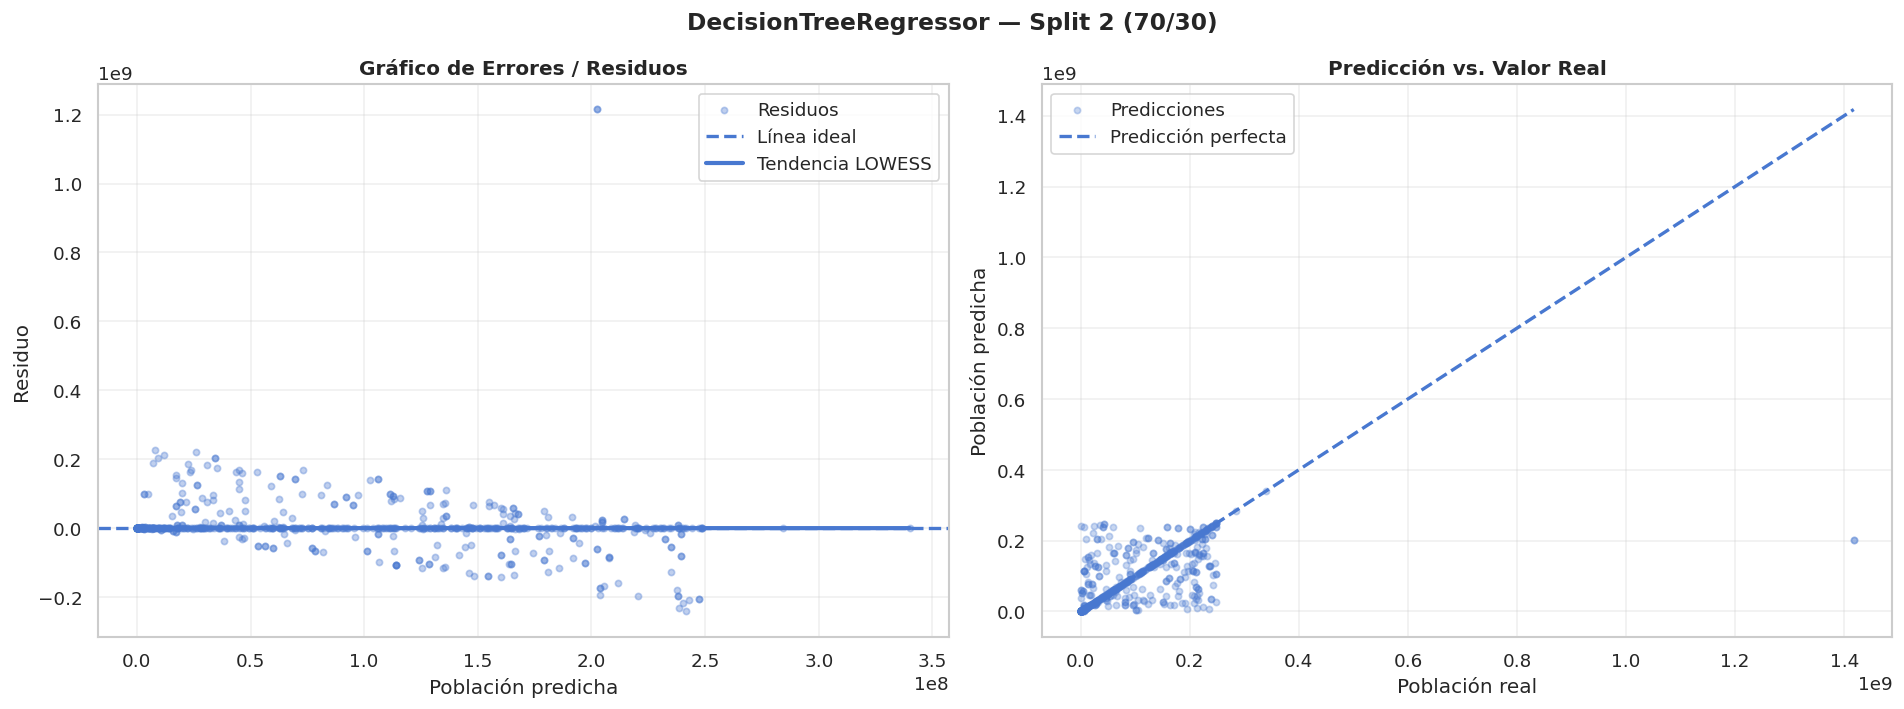

  💾 Gráfico guardado → /home/luis/Documents/STREAMLIT-PROYECTO/data/graficas/dtSplit_2_70-30.png


In [11]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 1,241 muestras  |  Test: 828 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.1929  (19.29%)
       → El modelo explica aproximadamente el 19.3%
         de la variación de la población según el área del país.
  MSE  (Error Cuadrático Med): 8771950764699631.0000
       → Penaliza más los errores grandes.
  RMSE (Raíz del MSE)        : 93658692.9478 habitantes
       → Error promedio en la misma unidad de la variable objetivo.
  MAE  (Error Absoluto Med)  : 42377292.4436 habitantes
       → Desviación promedio absoluta de las predicciones.


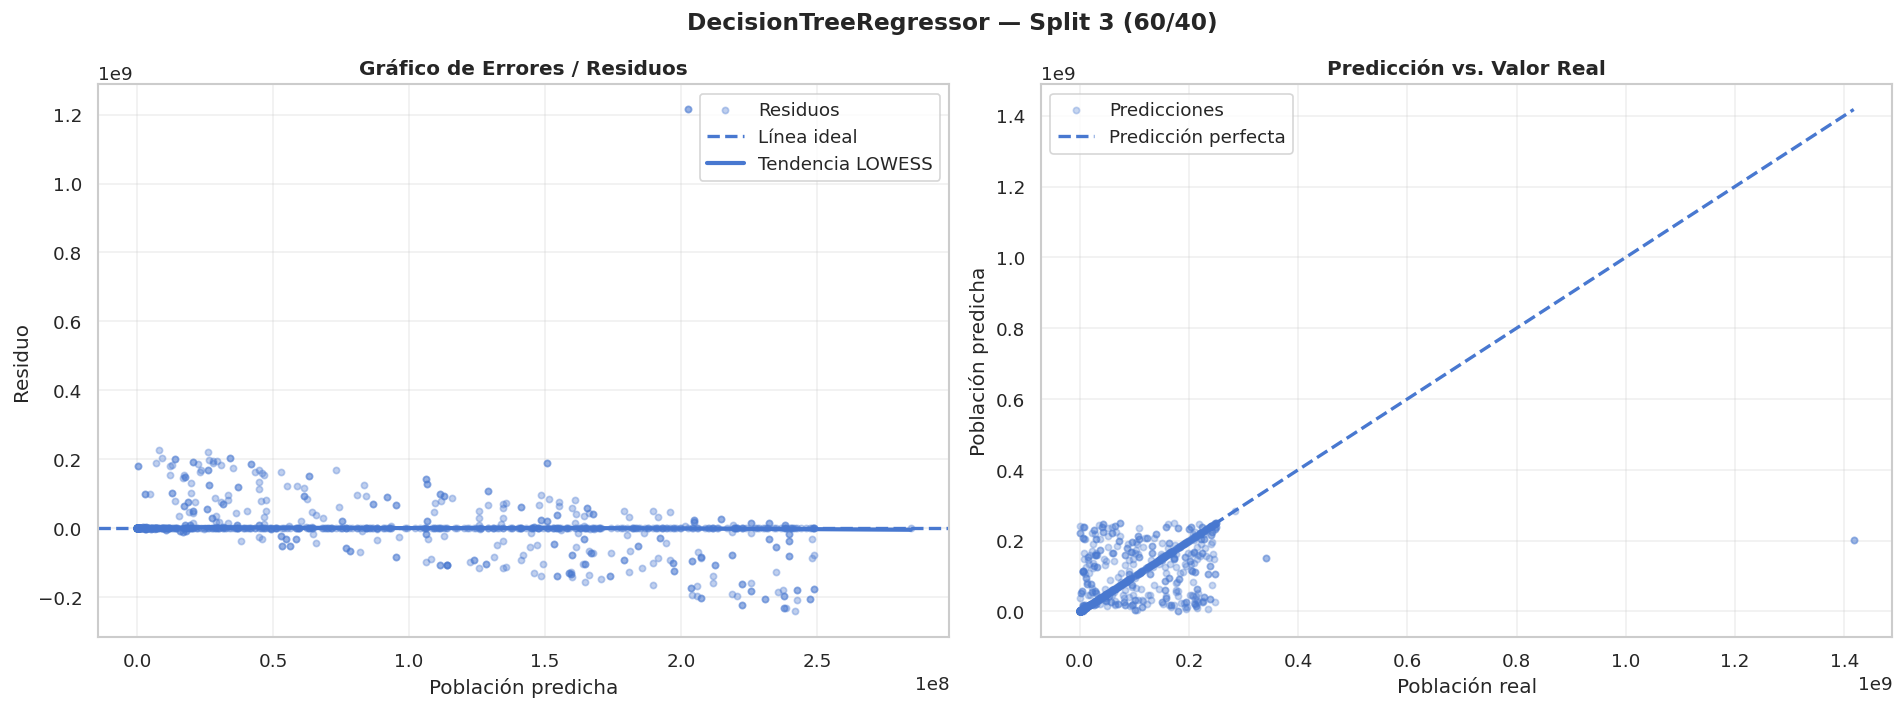

  💾 Gráfico guardado → /home/luis/Documents/STREAMLIT-PROYECTO/data/graficas/dtSplit_3_60-40.png


In [12]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)

In [14]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────

df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("        TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)

print(df_resumen.to_string(index=False))

print("=" * 65)

        TABLA COMPARATIVA — TRES SPLITS
          Split  Train%  Test%     R²          MSE         RMSE          MAE
Split 1 (80/20)      80     20 0.6969 3.282444e+15 5.729261e+07 2.708844e+07
Split 2 (70/30)      70     30 0.3015 8.627369e+15 9.288363e+07 3.562538e+07
Split 3 (60/40)      60     40 0.1929 8.771951e+15 9.365869e+07 4.237729e+07


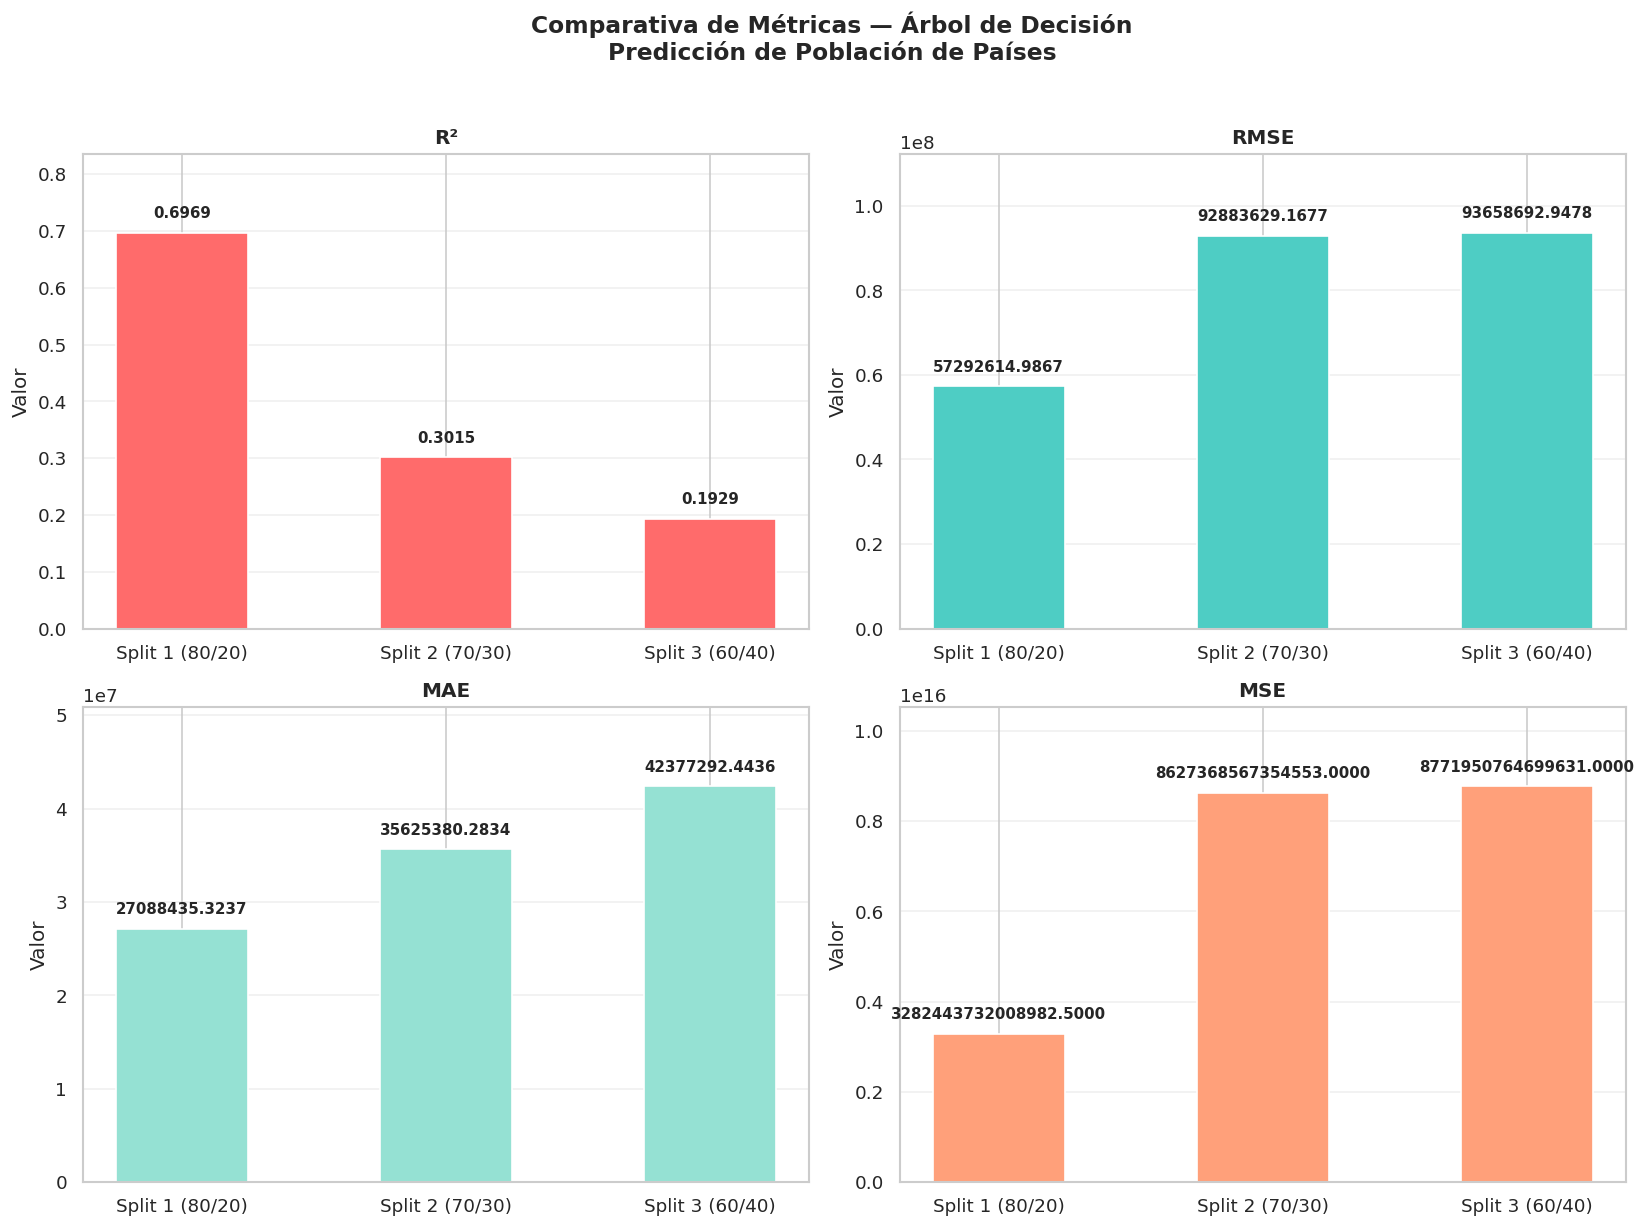

💾 Gráfico guardado → ../data/graficas/dt_metricas_paises.png


In [16]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────

metricas = ['R²', 'RMSE', 'MAE', 'MSE']

# mismos colores del profesor
colores = [
    '#ff6b6b',   # rojo
    '#4ecdc4',   # turquesa
    '#95e1d3',   # verde claro
    '#ffa07a'    # naranja
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

fig.suptitle(
    'Comparativa de Métricas — Árbol de Decisión\nPredicción de Población de Países',
    fontsize=14,
    fontweight='bold',
    y=1.02
)


# recorrer 4 métricas y 4 subplots
for ax, metrica, color in zip(axes.flat, metricas, colores):

    valores = df_resumen[metrica].values

    barras = ax.bar(
        df_resumen['Split'],
        valores,
        color=color,
        edgecolor='white',
        width=0.5
    )

    ax.set_title(
        metrica,
        fontweight='bold'
    )

    ax.set_ylabel('Valor')

    # Ajuste automático de altura
    ax.set_ylim(
        0,
        max(valores) * 1.20
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )


    # Mostrar valores encima de barras
    for bar, val in zip(barras, valores):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(valores) * 0.03),
            f'{val:.4f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )


plt.tight_layout()

plt.savefig(
    '../data/graficas/dt_metricas_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("💾 Gráfico guardado → ../data/graficas/dt_metricas_paises.png")

In [22]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────

r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max() - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 70)
print("   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor")
print("      Predicción: Área del país → Población")
print("=" * 70)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
""")

print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en los tres splits.
      Esto indica que el modelo mantiene un comportamiento parecido
      aunque cambie la proporción de datos de entrenamiento y prueba.
    """)
else:
    print("""
   ⚠️ El R² varía de forma notable entre los splits.
      Esto puede indicar que el modelo es sensible a la partición de datos
      o que el área por sí sola no explica completamente la población.
    """)

print("""
2. INTERPRETACIÓN DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si los residuos están dispersos alrededor de la línea 0,
     el modelo está prediciendo de forma más equilibrada.

   • Si los residuos muestran patrones fuertes, significa que el área
     no es suficiente para explicar la población de los países.

   • Un RMSE o MAE alto indica que las predicciones pueden alejarse mucho
     del valor real de población.

   • Esto es normal en este caso, porque países con poca área pueden tener
     mucha población, y países con mucha área pueden tener poca población.
""")

best_idx   = df_resumen['R²'].idxmax()
best_split = df_resumen.loc[best_idx, 'Split']
best_r2    = df_resumen.loc[best_idx, 'R²']
best_rmse  = df_resumen.loc[best_idx, 'RMSE']
best_mae   = df_resumen.loc[best_idx, 'MAE']

print(f"   Mejor split: {best_split} → R²={best_r2:.4f}, RMSE={best_rmse:.4f}, MAE={best_mae:.4f}")

print("""
3. RECOMENDACIÓN
────────────────
   A) Refinar el árbol de decisión:
      • Usar max_depth para limitar la profundidad del árbol.
      • Usar min_samples_leaf para evitar que el modelo memorice datos.
      • Probar diferentes configuraciones con GridSearchCV.

   B) Mejorar las variables del modelo:
      • Además del área, incluir región, subregión, latitud y longitud.
      • Esto puede ayudar a explicar mejor la distribución poblacional.

   C) Probar modelos más robustos:
      • RandomForestRegressor.
      • GradientBoostingRegressor.
      • XGBoost o LightGBM, si el proyecto lo permite.

   CONCLUSIÓN:
   El árbol de decisión permite analizar si existe una relación entre
   el área territorial y la población de los países. Sin embargo, usar
   solo el área como variable predictora puede limitar la precisión,
   porque la población depende también de factores económicos, sociales,
   geográficos e históricos.
""")

print("=" * 70)

   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor
      Predicción: Área del país → Población

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────

   R²   máx=0.6969  mín=0.1929  rango=0.5040
   RMSE máx=93658692.9478  mín=57292614.9867  rango=36366077.9611

   ⚠️ El R² varía de forma notable entre los splits.
      Esto puede indicar que el modelo es sensible a la partición de datos
      o que el área por sí sola no explica completamente la población.
    

2. INTERPRETACIÓN DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si los residuos están dispersos alrededor de la línea 0,
     el modelo está prediciendo de forma más equilibrada.

   • Si los residuos muestran patrones fuertes, significa que el área
     no es suficiente para explicar la población de los países.

   • Un RMSE o MAE alto indica que las predicciones pueden alejarse mucho
     del valor real de población.

   • Esto es normal en este caso, porque países con p

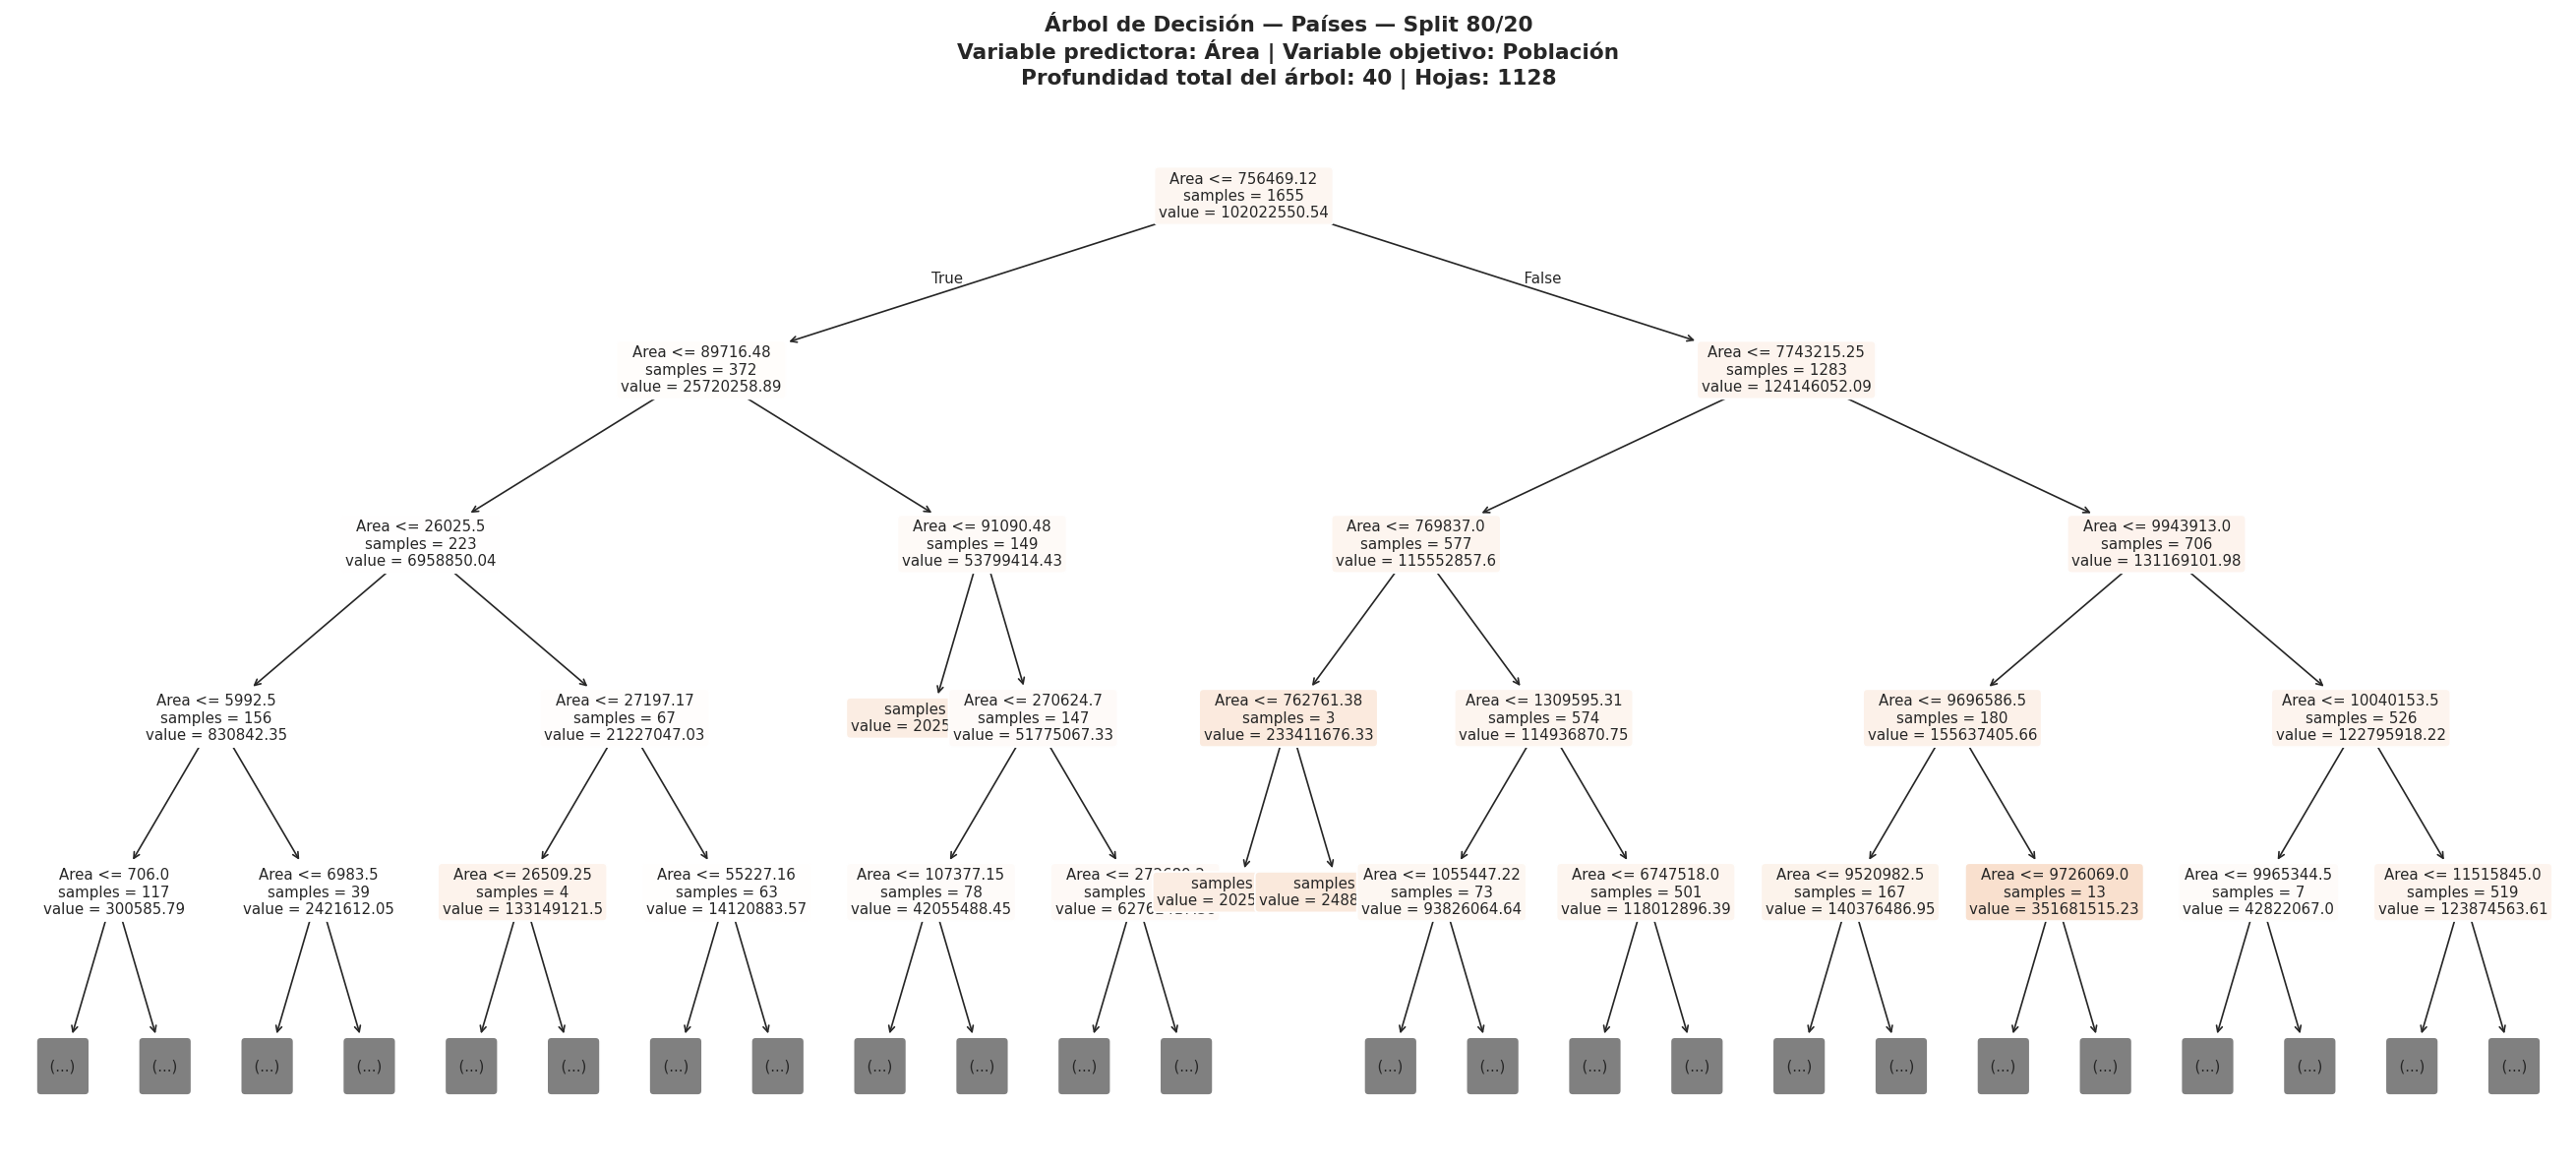

💾 Árbol real guardado → /home/luis/Documents/STREAMLIT-PROYECTO/data/graficas/dt_arbol_paises_4niveles.png

📐 Información del árbol completo (modelo_s1):
   Profundidad máxima : 40
   Número de hojas    : 1128
   Nodos totales      : 2255


In [23]:
# ── CELDA 11: Visualización del árbol real ───────────────────
from sklearn.tree import plot_tree, export_text
import os as _os

_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

# Árbol real del Split 1 truncado a 4 niveles
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=['Area'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión — Países — Split 80/20\n'
    'Variable predictora: Área | Variable objetivo: Población\n'
    f'Profundidad total del árbol: {modelo_s1.get_depth()} | '
    f'Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

fname_real = _os.path.join(_GRAFICAS, 'dt_arbol_paises_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')

plt.show()

print(f"💾 Árbol real guardado → {fname_real}")

print("\n📐 Información del árbol completo (modelo_s1):")
print(f"   Profundidad máxima : {modelo_s1.get_depth()}")
print(f"   Número de hojas    : {modelo_s1.get_n_leaves()}")
print(f"   Nodos totales      : {modelo_s1.tree_.node_count}")

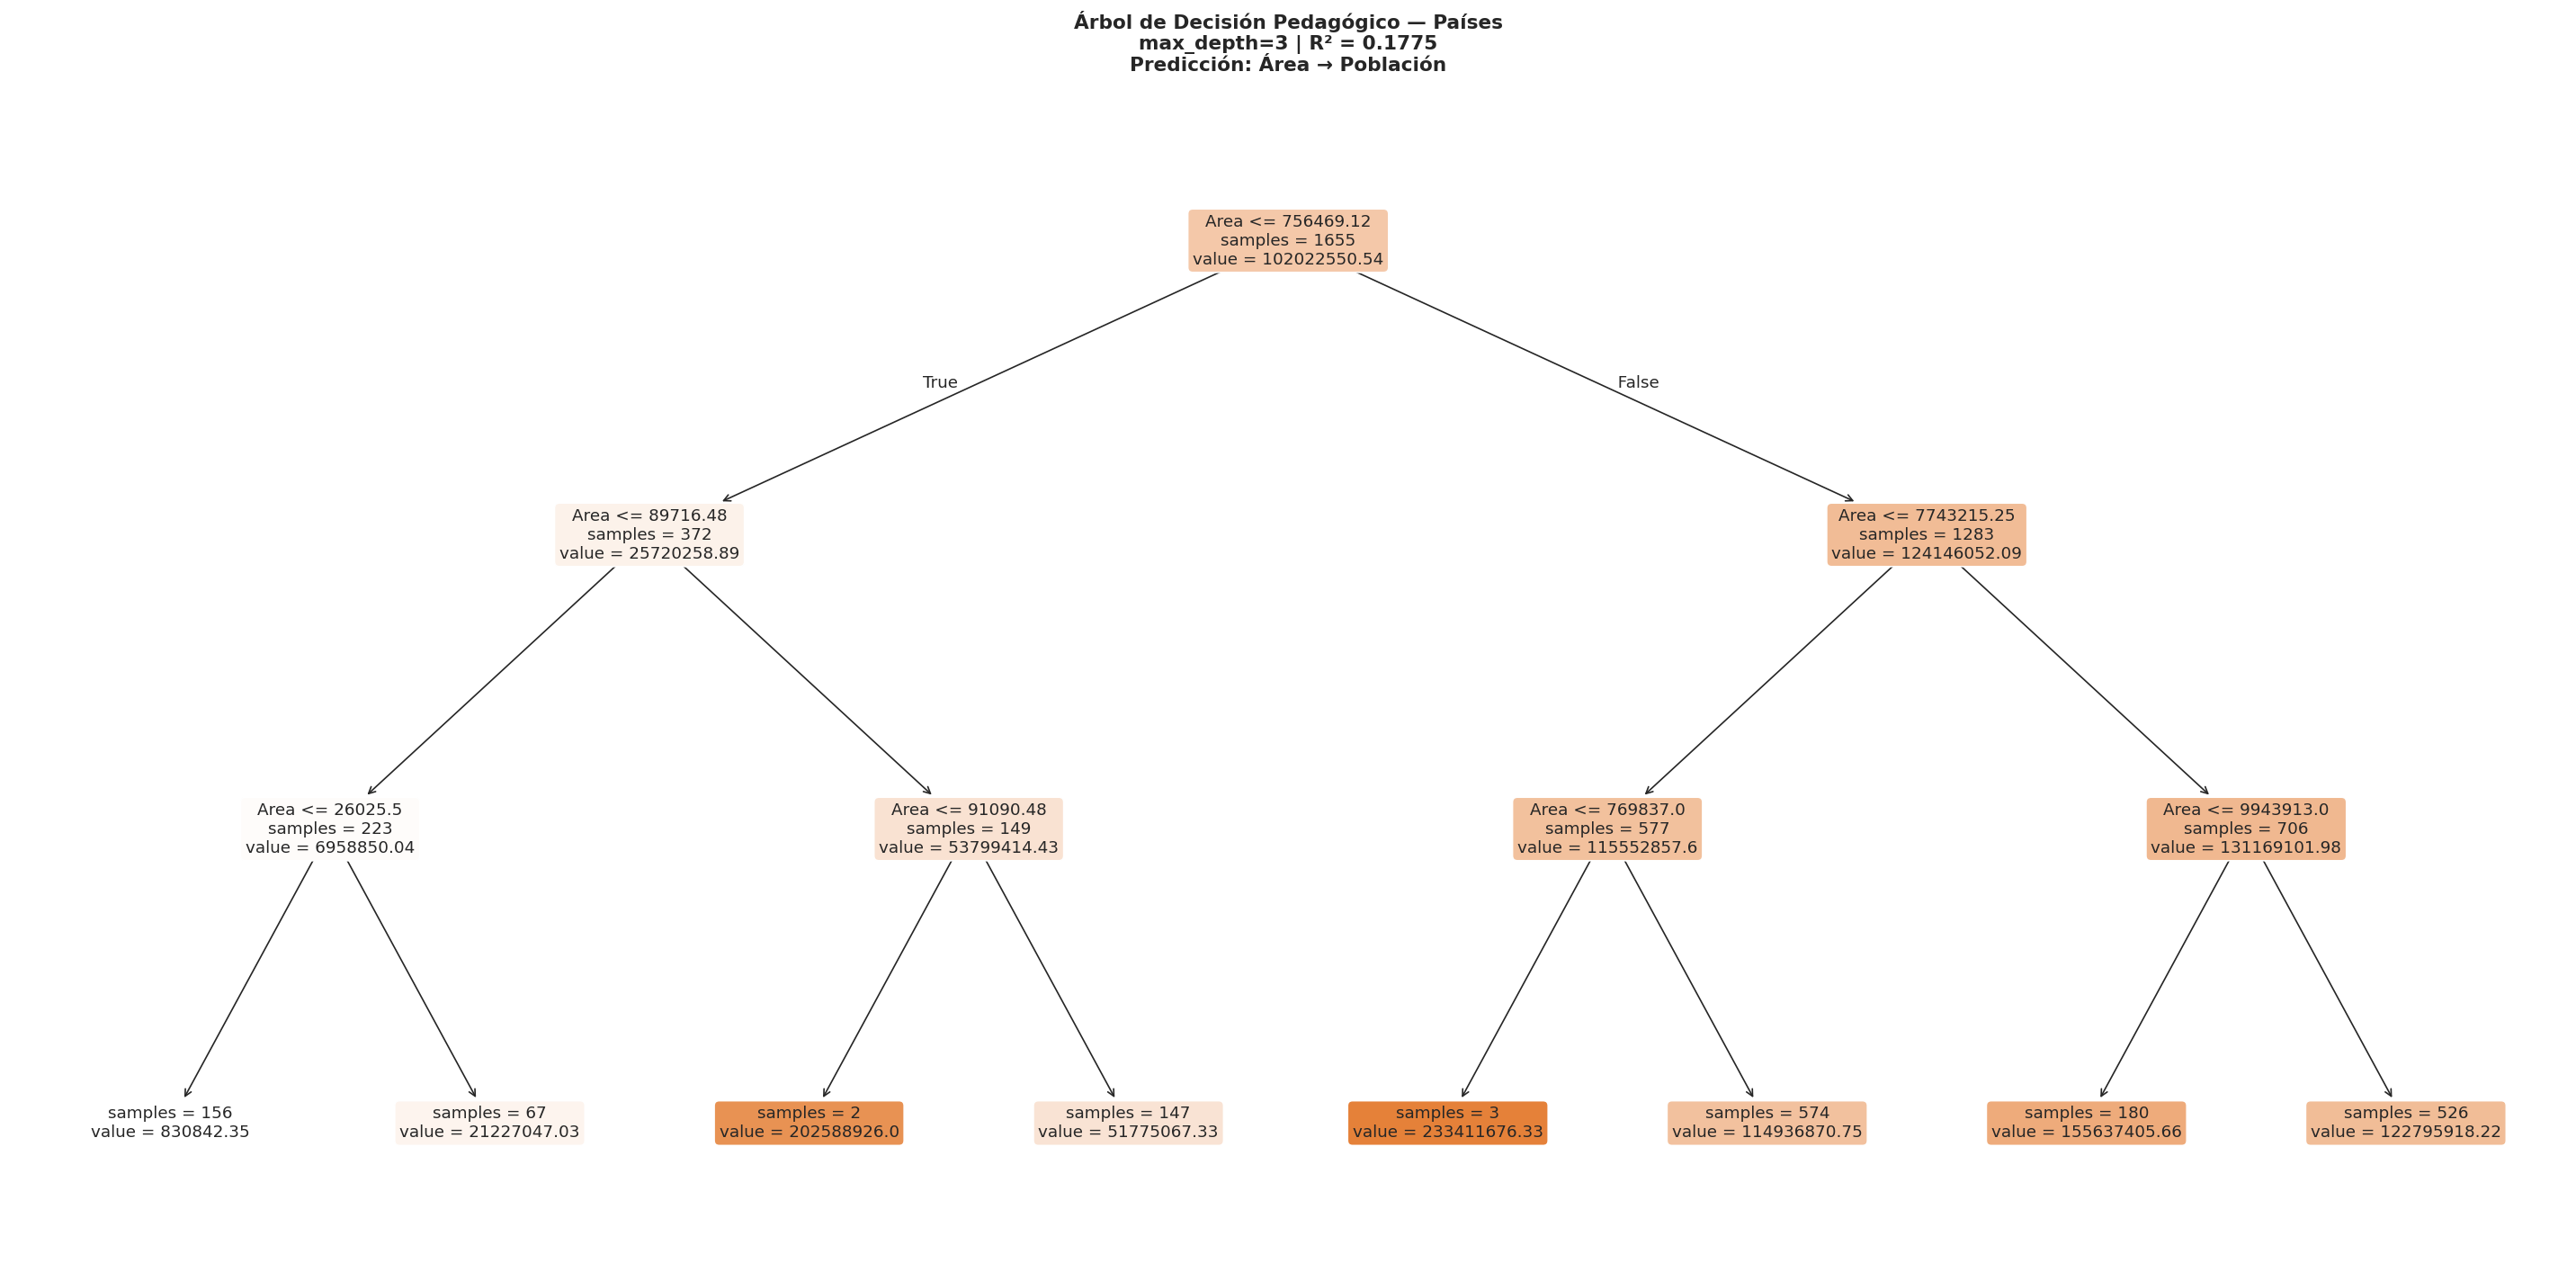

💾 Árbol pedagógico guardado → /home/luis/Documents/STREAMLIT-PROYECTO/data/graficas/dt_arbol_pedagogico_paises.png

📊 Rendimiento del árbol simplificado:
   R² = 0.1775

📌 Comparación:
   Árbol simplificado: 0.1775 | Árbol original: 0.6969


In [24]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import r2_score as _r2

# Reentrenar con max_depth=3 para visualización más clara
X_train_viz, X_test_viz, y_train_viz, y_test_viz = _tts(
    X,
    y,
    test_size=0.20,
    random_state=42
)

modelo_viz = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

modelo_viz.fit(X_train_viz, y_train_viz)

# Evaluación
r2_viz = _r2(
    y_test_viz,
    modelo_viz.predict(X_test_viz)
)

# Visualización
fig, ax = plt.subplots(figsize=(24, 12))

plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=['Area'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión Pedagógico — Países\n'
    f'max_depth=3 | R² = {r2_viz:.4f}\n'
    'Predicción: Área → Población',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

fname_ped = _os.path.join(
    _GRAFICAS,
    'dt_arbol_pedagogico_paises.png'
)

plt.savefig(
    fname_ped,
    dpi=180,
    bbox_inches='tight'
)

plt.show()

print(f"💾 Árbol pedagógico guardado → {fname_ped}")

print("\n📊 Rendimiento del árbol simplificado:")
print(f"   R² = {r2_viz:.4f}")

print("\n📌 Comparación:")
print(
    f"   Árbol simplificado: {r2_viz:.4f} "
    f"| Árbol original: {df_resumen.loc[0, 'R²']:.4f}"
)

In [25]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────

print("=" * 65)
print("   REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("=" * 65)

reglas = export_text(
    modelo_viz,
    feature_names=['Area']
)

print(reglas)

print("=" * 65)
print("📖 CÓMO LEER EL ÁRBOL:")
print("")
print("  |--- Area <= X.XX      → rama izquierda (condición verdadera)")
print("  |--- Area >  X.XX      → rama derecha  (condición falsa)")
print("  |--- value: [Y.YY]     → población estimada")
print("")
print("  El árbol evalúa el área del país en cada nodo.")
print("  Dependiendo de la condición, continúa hacia la")
print("  izquierda o derecha hasta llegar a una hoja.")
print("  El valor final de la hoja corresponde a la")
print("  población estimada por el modelo.")
print("")

print("=" * 65)

   REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- Area <= 756469.12
|   |--- Area <= 89716.48
|   |   |--- Area <= 26025.50
|   |   |   |--- value: [830842.35]
|   |   |--- Area >  26025.50
|   |   |   |--- value: [21227047.03]
|   |--- Area >  89716.48
|   |   |--- Area <= 91090.48
|   |   |   |--- value: [202588926.00]
|   |   |--- Area >  91090.48
|   |   |   |--- value: [51775067.33]
|--- Area >  756469.12
|   |--- Area <= 7743215.25
|   |   |--- Area <= 769837.00
|   |   |   |--- value: [233411676.33]
|   |   |--- Area >  769837.00
|   |   |   |--- value: [114936870.75]
|   |--- Area >  7743215.25
|   |   |--- Area <= 9943913.00
|   |   |   |--- value: [155637405.66]
|   |   |--- Area >  9943913.00
|   |   |   |--- value: [122795918.22]

📖 CÓMO LEER EL ÁRBOL:

  |--- Area <= X.XX      → rama izquierda (condición verdadera)
  |--- Area >  X.XX      → rama derecha  (condición falsa)
  |--- value: [Y.YY]     → población estimada

  El árbol evalúa el área del país en cada n